Delay time distributions 

In [3]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl
import tol_colors as tc

# Add the subdir to sys.path for our created scripts
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')

# Now you can import the module
import useful_fncs
import utils_from_others
import figure_utils

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

In [219]:
# let's read in our files 

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# merging conditions
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers = Merges_Hubble_Time == True


In [202]:
# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixture_weights_merged = mixture_weights_all[DCO_mask_NSNS*condition_mergers]

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes_merged = lifetimes_all[DCO_mask_NSNS*condition_mergers]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times_merged = col_times_all[DCO_mask_NSNS*condition_mergers]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_all = lifetimes_all + col_times_all
delay_times_merged = lifetimes_merged + col_times_merged

In [203]:
# checking untis of the times
print(DCOs_NSNS['Time'].attrs['units']) 
print(DCOs_NSNS['Coalescence_Time'].attrs['units']) 

b'Myr'
b'Myr'


In [204]:
# let's find the delay time dist for our subselections of interest

# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_merged = stellar_types_all_1[DCO_mask_NSNS*condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_merged = stellar_types_all_2[DCO_mask_NSNS*condition_mergers]

# for all systems
# NSNS bool
NSNS_systems_bool = np.logical_and(stellar_types_all_1==13, stellar_types_all_2==13)

# WDWD bool
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_all_1, stellar_types_all_2)
carbon_oxygen_bool_WDWD = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))


# for systems that have merged
# NSNS bool
NSNS_systems_bool_merged = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

# WDWD bool
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged, stellar_types_2_merged)
carbon_oxygen_bool_WDWD_merged = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

In [205]:
np.shape(delay_times_all)

(1418671,)

In [206]:
# gathering the weights and delay times for all 

# NSNS
delay_times_NSNS = delay_times_all[NSNS_systems_bool]
mixture_weights_NSNS = mixture_weights_all[NSNS_systems_bool]

# WDWD
delay_times_WDWD = delay_times_all[carbon_oxygen_bool_WDWD]
mixture_weights_WDWD = mixture_weights_all[carbon_oxygen_bool_WDWD]

In [207]:
# gathering the weights and delay times for each of these merged systems

# NSNS
delay_times_merged_NSNS = delay_times_merged[NSNS_systems_bool_merged]
mixture_weights_merged_NSNS = mixture_weights_merged[NSNS_systems_bool_merged]

# WDWD
delay_times_merged_WDWD = delay_times_merged[carbon_oxygen_bool_WDWD_merged]
mixture_weights_merged_WDWD = mixture_weights_merged[carbon_oxygen_bool_WDWD_merged]

### Plotting all of systems

Text(0.5, 0.98, 'NSNS Optimized: N5e6_NSNS_CE_alpha025')

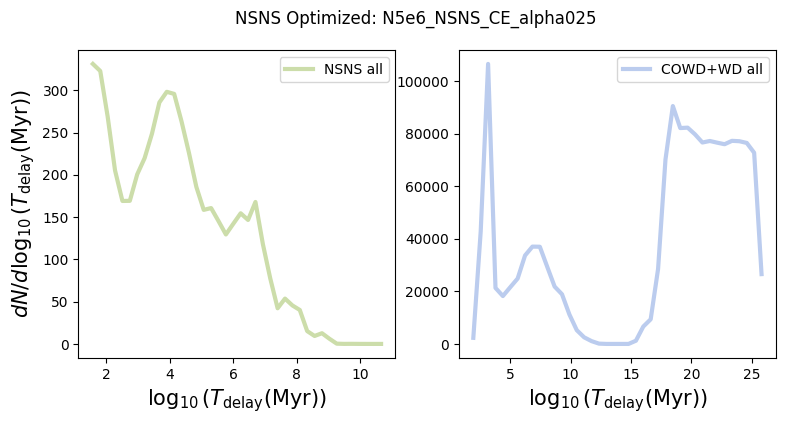

In [68]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(np.log10(delay_times_NSNS), weights=mixture_weights_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(mixture_weights_NSNS)

axs[0].plot(bin_centers, hist*normalization, color=cset.pale_green, lw=3, label='NSNS all')

# plt.yscale('log')
# plt.ylim(10**-8, 10**-5)

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend()

# WDWD
hist_WDWD, bin_edges_WDWD = np.histogram(np.log10(delay_times_WDWD), weights=mixture_weights_WDWD, bins=40, density=True)

bin_centers_WDWD = (bin_edges_WDWD[0:-1] + bin_edges_WDWD[1:])/2
normalization_WDWD = np.sum(mixture_weights_WDWD)

axs[1].plot(bin_centers_WDWD, hist_WDWD*normalization_WDWD, color=cset.pale_blue, lw=3, label='COWD+WD all')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend()

fig.suptitle('NSNS Optimized: N5e6_NSNS_CE_alpha025')

### Plotting systems that merge in a Hubble Time

Text(0.5, 0.98, 'NSNS Optimized: N5e6_NSNS_CE_alpha025')

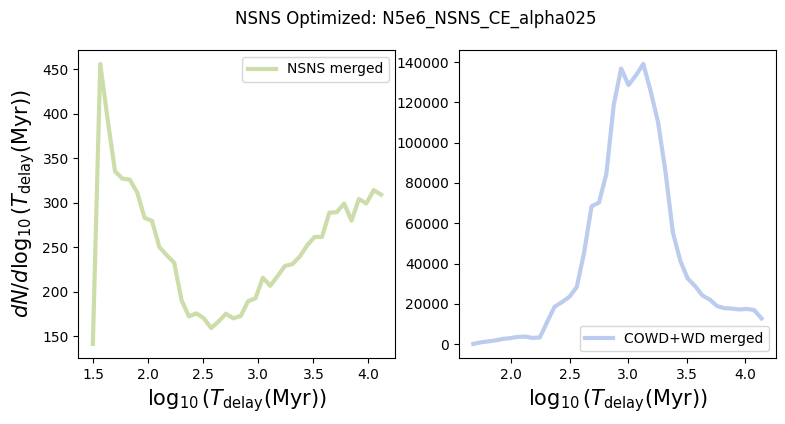

In [69]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(np.log10(delay_times_merged_NSNS), weights=mixture_weights_merged_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(mixture_weights_merged_NSNS)

axs[0].plot(bin_centers, hist*normalization, color=cset.pale_green, lw=3, label='NSNS merged')

# plt.yscale('log')
# plt.ylim(10**-8, 10**-5)

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend()

# WDWD
hist_WDWD, bin_edges_WDWD = np.histogram(np.log10(delay_times_merged_WDWD), weights=mixture_weights_merged_WDWD, bins=40, density=True)

bin_centers_WDWD = (bin_edges_WDWD[0:-1] + bin_edges_WDWD[1:])/2
normalization_WDWD = np.sum(mixture_weights_merged_WDWD)

axs[1].plot(bin_centers_WDWD, hist_WDWD*normalization_WDWD, color=cset.pale_blue, lw=3, label='COWD+WD merged')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend()

fig.suptitle('NSNS Optimized: N5e6_NSNS_CE_alpha025')

In [70]:
Data_NSNS.close()

## WDWD optimized system

In [208]:
# let's read in our files 

## WDWD optimized run

# let's first look at the NSNS_output
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# merging conditions
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers_WDopt = Merges_Hubble_Time_WDopt == True


In [209]:
# making sure we are rpesenting the true universe
mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixture_weights_merged_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# times (these should be in Myr)
lifetimes_all_WDopt = DCOs_WDWD['Time'][()]
lifetimes_merged_WDopt = lifetimes_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

col_times_all_WDopt = DCOs_WDWD['Coalescence_Time'][()]
col_times_merged_WDopt = col_times_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_all_WDopt = lifetimes_all_WDopt + col_times_all_WDopt
delay_times_merged_WDopt = lifetimes_merged_WDopt + col_times_merged_WDopt

In [210]:
# let's find the delay time dist for our subselections of interest

# selecting for NSNS
stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_merged_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

stellar_types_all_2_WDopt = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_merged_WDopt = stellar_types_all_2_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# for all systems
# NSNS bool
NSNS_systems_bool_WDopt = np.logical_and(stellar_types_all_1_WDopt==13, stellar_types_all_2_WDopt==13)

# WDWD bool
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_all_1_WDopt, stellar_types_all_2_WDopt)
carbon_oxygen_bool_WDWD_WDopt = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))


# for systems that have merged
# NSNS bool
NSNS_systems_bool_merged_WDopt = np.logical_and(stellar_types_1_merged_WDopt==13, stellar_types_2_merged_WDopt==13)

# WDWD bool
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

In [211]:
# gathering the weights and delay times for all 

# NSNS
delay_times_NSNS_WDopt = delay_times_all_WDopt[NSNS_systems_bool_WDopt]
mixture_weights_NSNS_WDopt = mixture_weights_all_WDopt[NSNS_systems_bool_WDopt]

# WDWD
delay_times_WDWD_WDopt = delay_times_all_WDopt[carbon_oxygen_bool_WDWD_WDopt]
mixture_weights_WDWD_WDopt = mixture_weights_all_WDopt[carbon_oxygen_bool_WDWD_WDopt]

In [212]:
# gathering the weights and delay times for each of these merged systems

# NSNS
delay_times_merged_NSNS_WDopt = delay_times_merged_WDopt[NSNS_systems_bool_merged_WDopt]
mixture_weights_merged_NSNS_WDopt = mixture_weights_merged_WDopt[NSNS_systems_bool_merged_WDopt]

# WDWD
delay_times_merged_WDWD_WDopt = delay_times_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]
mixture_weights_merged_WDWD_WDopt = mixture_weights_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

### Plotting!

Text(0.5, 0.98, 'WDWD Optimized: N5e6_NSNS_CE_alpha025')

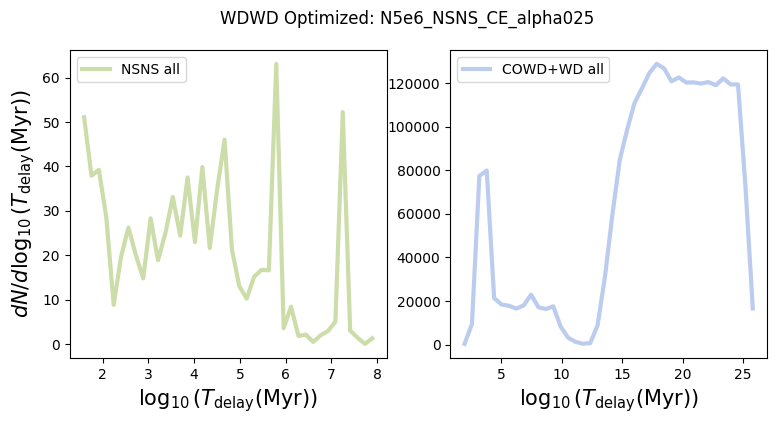

In [102]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist_WDopt, bin_edges_WDopt = np.histogram(np.log10(delay_times_NSNS_WDopt), weights=mixture_weights_NSNS_WDopt, bins=40, density=True)

bin_centers_WDopt = (bin_edges_WDopt[0:-1] + bin_edges_WDopt[1:])/2
normalization_WDopt = np.sum(mixture_weights_NSNS_WDopt)

axs[0].plot(bin_centers_WDopt, hist_WDopt*normalization_WDopt, color=cset.pale_green, lw=3, label='NSNS all')

# plt.yscale('log')
# plt.ylim(10**-8, 10**-5)

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend()

# WDWD
hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(np.log10(delay_times_WDWD_WDopt), weights=mixture_weights_WDWD_WDopt, bins=40, density=True)

bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2
normalization_WDWD_WDopt = np.sum(mixture_weights_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_WDopt, hist_WDWD_WDopt*normalization_WDWD_WDopt, color=cset.pale_blue, lw=3, label='COWD+WD all')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend()

fig.suptitle('WDWD Optimized: N5e6_NSNS_CE_alpha025')

#### Plotting for just the merged systems for WDWD optimized

In [1]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(9, 4))

cset = tc.pale

# NSNS
hist_merged_WDopt, bin_edges_merged_WDopt = np.histogram(np.log10(delay_times_merged_NSNS_WDopt), weights=mixture_weights_merged_NSNS_WDopt, bins=40, density=True)

bin_centers_merged_WDopt = (bin_edges_merged_WDopt[0:-1] + bin_edges_merged_WDopt[1:])/2
normalization_merged_WDopt = np.sum(mixture_weights_merged_NSNS_WDopt)

axs[0].plot(bin_centers_merged_WDopt, hist_merged_WDopt*normalization_merged_WDopt, color=cset.pale_green, lw=3, label='NSNS merged')

# hist_WDopt, bin_edges_WDopt = np.histogram(np.log10(delay_times_NSNS_WDopt), weights=mixture_weights_NSNS_WDopt, bins=40, density=True)

# bin_centers_WDopt = (bin_edges_WDopt[0:-1] + bin_edges_WDopt[1:])/2
# normalization_WDopt = np.sum(mixture_weights_NSNS_WDopt)

# axs[0].plot(bin_centers_WDopt, hist_WDopt*normalization_WDopt, color=cset.pale_green, lw=3, label='WDWD optimized: NSNS all')

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend()

# WDWD
hist_WDWD_merged_WDopt, bin_edges_WDWD_merged_WDopt = np.histogram(np.log10(delay_times_merged_WDWD_WDopt), weights=mixture_weights_merged_WDWD_WDopt, bins=40, density=True)

bin_centers_WDWD_merged_WDopt = (bin_edges_WDWD_merged_WDopt[0:-1] + bin_edges_WDWD_merged_WDopt[1:])/2
normalization_WDWD_merged_WDopt = np.sum(mixture_weights_merged_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_merged_WDopt, hist_WDWD_merged_WDopt*normalization_WDWD_merged_WDopt, color=cset.pale_blue, lw=3, label='COWD+WD merged')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend()

fig.suptitle('WDWD Optimized: N5e6_NSNS_CE_alpha025')

NameError: name 'plt' is not defined

## Plotting things all together

Text(0.5, 0.98, 'N5e6_NSNS_CE_alpha05 - all systems')

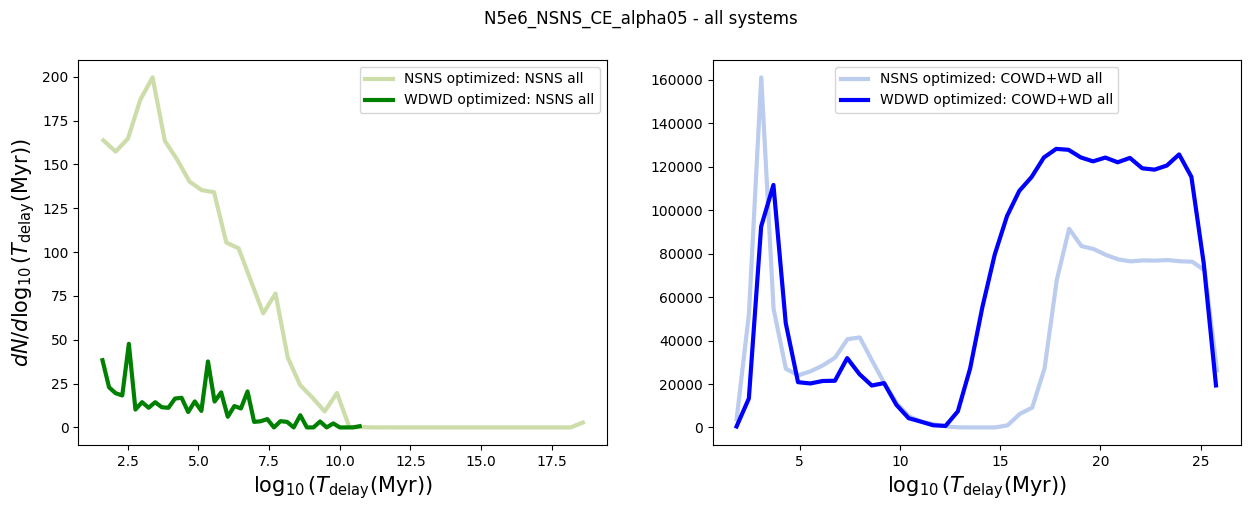

In [214]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(15, 5))

cset = tc.pale

### NSNS
hist, bin_edges = np.histogram(np.log10(delay_times_NSNS), weights=mixture_weights_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(mixture_weights_NSNS)

axs[0].plot(bin_centers, hist*normalization, color=cset.pale_green, lw=3, label='NSNS optimized: NSNS all')

hist_WDopt, bin_edges_WDopt = np.histogram(np.log10(delay_times_NSNS_WDopt), weights=mixture_weights_NSNS_WDopt, bins=40, density=True)

bin_centers_WDopt = (bin_edges_WDopt[0:-1] + bin_edges_WDopt[1:])/2
normalization_WDopt = np.sum(mixture_weights_NSNS_WDopt)

axs[0].plot(bin_centers_WDopt, hist_WDopt*normalization_WDopt, color='green', lw=3, label='WDWD optimized: NSNS all')

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend()
# axs[0].set_yscale('log')
# axs[0].set_ylim(10**-2, 10**3)


### WDWD
hist_WDWD, bin_edges_WDWD = np.histogram(np.log10(delay_times_WDWD), weights=mixture_weights_WDWD, bins=40, density=True)

bin_centers_WDWD = (bin_edges_WDWD[0:-1] + bin_edges_WDWD[1:])/2
normalization_WDWD = np.sum(mixture_weights_WDWD)

axs[1].plot(bin_centers_WDWD, hist_WDWD*normalization_WDWD, color=cset.pale_blue, lw=3, label='NSNS optimized: COWD+WD all')

hist_WDWD_WDopt, bin_edges_WDWD_WDopt = np.histogram(np.log10(delay_times_WDWD_WDopt), weights=mixture_weights_WDWD_WDopt, bins=40, density=True)

bin_centers_WDWD_WDopt = (bin_edges_WDWD_WDopt[0:-1] + bin_edges_WDWD_WDopt[1:])/2
normalization_WDWD_WDopt = np.sum(mixture_weights_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_WDopt, hist_WDWD_WDopt*normalization_WDWD_WDopt, color='blue', lw=3, label='WDWD optimized: COWD+WD all')

# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend(loc='upper center')

fig.suptitle('N5e6_NSNS_CE_alpha05 - all systems')

Text(0.5, 0.98, 'N5e6_NSNS_CE_alpha05 - merged systems')

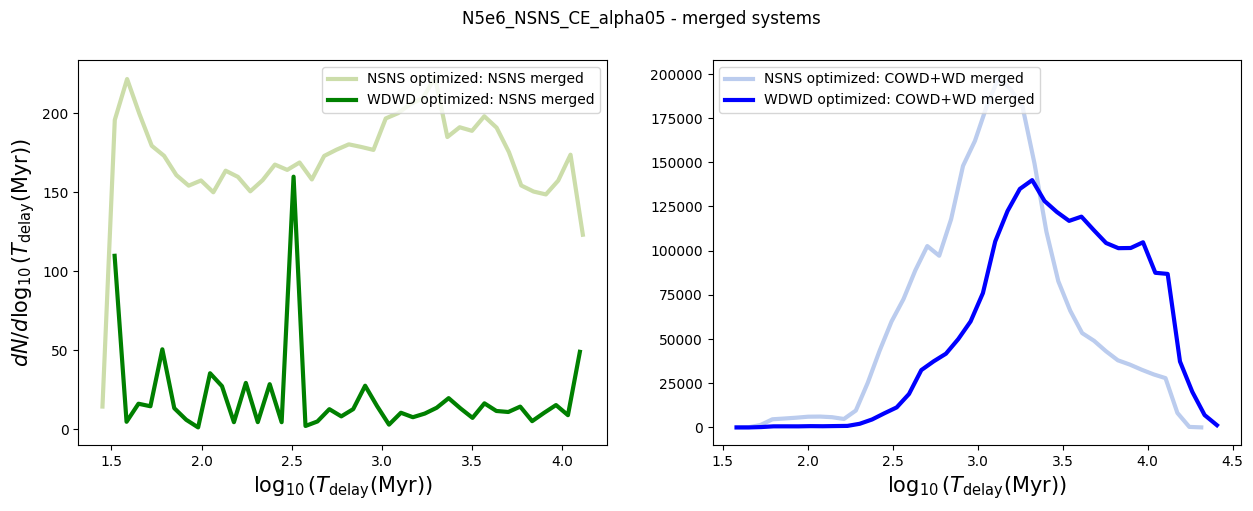

In [216]:
# plotting delay time dist
fig, axs = plt.subplots(1,2, figsize=(15, 5))

cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(np.log10(delay_times_merged_NSNS), weights=mixture_weights_merged_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(mixture_weights_merged_NSNS)

axs[0].plot(bin_centers, hist*normalization, color=cset.pale_green, lw=3, label='NSNS optimized: NSNS merged')

hist_merged_WDopt, bin_edges_merged_WDopt = np.histogram(np.log10(delay_times_merged_NSNS_WDopt), weights=mixture_weights_merged_NSNS_WDopt, bins=40, density=True)

bin_centers_merged_WDopt = (bin_edges_merged_WDopt[0:-1] + bin_edges_merged_WDopt[1:])/2
normalization_merged_WDopt = np.sum(mixture_weights_merged_NSNS_WDopt)

axs[0].plot(bin_centers_merged_WDopt, hist_merged_WDopt*normalization_merged_WDopt, color='green', lw=3, label='WDWD optimized: NSNS merged')

# plt.yscale('log')
# plt.ylim(10**-8, 10**-5)

axs[0].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[0].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[0].legend(loc='upper right')
# axs[0].set_yscale('log')

# WDWD
hist_WDWD, bin_edges_WDWD = np.histogram(np.log10(delay_times_merged_WDWD), weights=mixture_weights_merged_WDWD, bins=40, density=True)

bin_centers_WDWD = (bin_edges_WDWD[0:-1] + bin_edges_WDWD[1:])/2
normalization_WDWD = np.sum(mixture_weights_merged_WDWD)

axs[1].plot(bin_centers_WDWD, hist_WDWD*normalization_WDWD, color=cset.pale_blue, lw=3, label='NSNS optimized: COWD+WD merged')

hist_WDWD_merged_WDopt, bin_edges_WDWD_merged_WDopt = np.histogram(np.log10(delay_times_merged_WDWD_WDopt), weights=mixture_weights_merged_WDWD_WDopt, bins=40, density=True)

bin_centers_WDWD_merged_WDopt = (bin_edges_WDWD_merged_WDopt[0:-1] + bin_edges_WDWD_merged_WDopt[1:])/2
normalization_WDWD_merged_WDopt = np.sum(mixture_weights_merged_WDWD_WDopt)

axs[1].plot(bin_centers_WDWD_merged_WDopt, hist_WDWD_merged_WDopt*normalization_WDWD_merged_WDopt, color='blue', lw=3, label='WDWD optimized: COWD+WD merged')


# axs[1].set_ylabel(r'$dN/d\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)
axs[1].set_xlabel(r'$\log_{10}(T_{\mathrm{delay}}(\mathrm{Myr}))$', fontsize=15)

axs[1].legend(loc='upper left')

fig.suptitle('N5e6_NSNS_CE_alpha05 - merged systems')

In [220]:
Data_NSNS.close()

In [221]:
Data_WDWD.close()